# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [56]:
#importar las librerias

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

In [57]:
# Cargar los datos
data = pd.read_csv('/datasets/taxi.csv', parse_dates=[0])
print(data.info)
print(data.head)

<bound method DataFrame.info of                  datetime  num_orders
0     2018-03-01 00:00:00           9
1     2018-03-01 00:10:00          14
2     2018-03-01 00:20:00          28
3     2018-03-01 00:30:00          20
4     2018-03-01 00:40:00          32
...                   ...         ...
26491 2018-08-31 23:10:00          32
26492 2018-08-31 23:20:00          24
26493 2018-08-31 23:30:00          27
26494 2018-08-31 23:40:00          39
26495 2018-08-31 23:50:00          53

[26496 rows x 2 columns]>
<bound method NDFrame.head of                  datetime  num_orders
0     2018-03-01 00:00:00           9
1     2018-03-01 00:10:00          14
2     2018-03-01 00:20:00          28
3     2018-03-01 00:30:00          20
4     2018-03-01 00:40:00          32
...                   ...         ...
26491 2018-08-31 23:10:00          32
26492 2018-08-31 23:20:00          24
26493 2018-08-31 23:30:00          27
26494 2018-08-31 23:40:00          39
26495 2018-08-31 23:50:00          53

In [58]:
# Establecer fecha como índice
data.set_index('datetime', inplace=True)

# Ordenar por índice
data.sort_index(inplace=True)

# Remuestreo a intervalos de 1 hora
data = data.resample('1H').sum()

# Revision
print(data.info())
print(data.head())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: H
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB
None
                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43


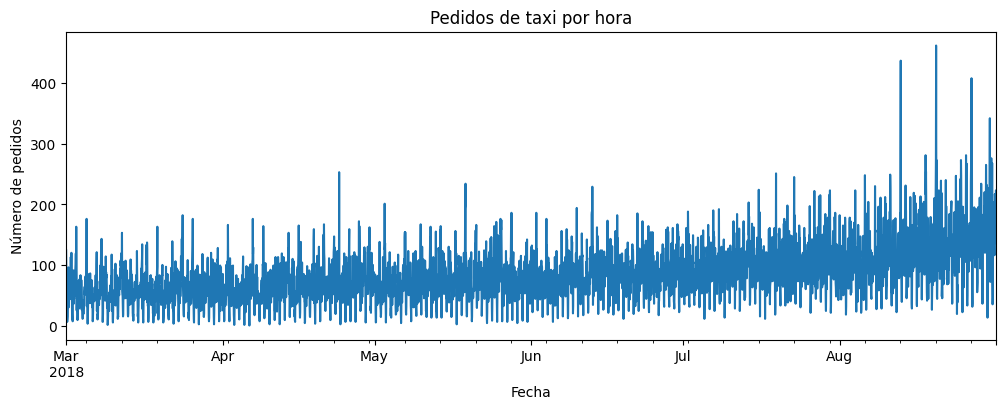

In [59]:
# Gráfico inicial para ver comportamiento general
data['num_orders'].plot(figsize=(12,4))
plt.title("Pedidos de taxi por hora")
plt.xlabel("Fecha")
plt.ylabel("Número de pedidos")
plt.show()

## Análisis

- Después de cargar el archivo taxi.csv, se convirtió la columna de fecha a un índice de tipo DatetimeIndex, se ordenó el dataset cronológicamente y se realizó un remuestreo a intervalos de una hora.

- Tras este proceso, el conjunto final quedó con 4416 registros, cada uno representando el número total de órdenes de taxi recibidas en cada hora del periodo comprendido entre marzo y agosto de 2018.

- A partir del método .info() se verificó que la columna num_orders no contiene valores ausentes, lo cual permite continuar el análisis sin necesidad de imputación adicional.

El gráfico inicial muestra varios patrones importantes:

- Existe una fuerte variabilidad en la cantidad de pedidos por hora, oscilando entre valores bajos durante muchas horas del día y picos considerables en ciertos momentos.
- Se observan incrementos progresivos hacia el final del periodo, lo cual sugiere una posible tendencia creciente general.
- También se aprecian fluctuaciones abruptas, compatibles con estacionalidad diaria o semanal típica del transporte (horas pico, fines de semana, etc.).
- Los picos más altos superan los 100 pedidos por hora, indicando momentos de demanda extrema.

En conjunto, estos resultados sugieren que la serie temporal contiene una mezcla de estacionalidad, tendencia, y variación aleatoria, lo que hace adecuado el uso de modelos de series temporales con características adicionales como lags o ventanas móviles para mejorar la predicción de la hora siguiente.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien realizadas las gráficas para analizar los datos considerando el tipo de problema a resolver, que en este caso es serie de tiempo
</div>

## Formación

Se crea una función make_features() para generar atributos
- Año
- Mes
- Día
- Día de la semana
- Lags (retrasos)
- Media móvil

In [60]:
def make_features(data, max_lag=24, rolling_mean_size=24):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    
    # Lags
    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['num_orders'].shift(lag)
    
    # Rolling mean sin fuga de información
    data['rolling_mean'] = data['num_orders'].shift(1).rolling(rolling_mean_size).mean()
    
    return data

In [61]:
#Aplicar la función al dataset
data_features = make_features(data.copy(), max_lag=24, rolling_mean_size=24)

In [62]:
# Dividir en Train y Test

train, test = train_test_split(data_features, shuffle=False, test_size=0.1)

# Eliminar NaN del train, generados por los lags y rolling mean
train = train.dropna()

In [63]:
#Seleccionar caracteristicas y objeto
target = 'num_orders'
features = train.columns.drop(target)

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, realizaste los ajustes de las características en el dataset de manera adecuada para obtener un buen desempeño en los entrenamientos
    
</div>

### Regresión lineal

In [64]:
# entrenar un modelo base, regresión lineal
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_train_lr = model_lr.predict(X_train)
pred_test_lr = model_lr.predict(X_test)

In [65]:
#Calcular RMSE (RECM)
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train_lr))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test_lr))

print("RMSE Train:", rmse_train)
print("RMSE Test:", rmse_test)

RMSE Train: 25.818602103995378
RMSE Test: 45.52933708020937


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien! Lograste una métrica por debajo de lo requerido para este proyecto demostrando que el modelo pudo interpretar de manera adecuada tus datos para la predicción
</div>

### Random Forest

In [66]:
rf_model = RandomForestRegressor(
    n_estimators=300,   # número de árboles
    max_depth=15,       # profundidad máxima
    random_state=42,
    n_jobs=-1           # usa todos los cores disponibles
)

rf_model.fit(X_train, y_train)

# Predicciones
pred_train_rf = rf_model.predict(X_train)
pred_test_rf = rf_model.predict(X_test)

# RMSE
rmse_train_rf = np.sqrt(mean_squared_error(y_train, pred_train_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, pred_test_rf))

print("Random Forest - RMSE Train:", rmse_train_rf)
print("Random Forest - RMSE Test:", rmse_test_rf)

Random Forest - RMSE Train: 9.755721663974008
Random Forest - RMSE Test: 43.394907914786494


In [67]:
param_grid = [
    (100, 8),
    (200, 12),
    (300, 15),
]

for n_est, depth in param_grid:
    model = RandomForestRegressor(
        n_estimators=n_est,
        max_depth=depth,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    print(f"n_estimators={n_est}, max_depth={depth} -> RMSE Test = {rmse:.2f}")

n_estimators=100, max_depth=8 -> RMSE Test = 44.51
n_estimators=200, max_depth=12 -> RMSE Test = 43.61
n_estimators=300, max_depth=15 -> RMSE Test = 43.39


### Gradient Boosting

In [68]:
gbr_model = GradientBoostingRegressor(
    n_estimators=300,    # número de árboles débiles
    learning_rate=0.05,  # tamaño del paso
    max_depth=3,        # profundidad de cada árbol
    random_state=42
)

gbr_model.fit(X_train, y_train)

# Predicciones
pred_train_gbr = gbr_model.predict(X_train)
pred_test_gbr = gbr_model.predict(X_test)

# RMSE
rmse_train_gbr = np.sqrt(mean_squared_error(y_train, pred_train_gbr))
rmse_test_gbr = np.sqrt(mean_squared_error(y_test, pred_test_gbr))

print("Gradient Boosting - RMSE Train:", rmse_train_gbr)
print("Gradient Boosting - RMSE Test:", rmse_test_gbr)

Gradient Boosting - RMSE Train: 19.31811224278561
Gradient Boosting - RMSE Test: 44.547910348765946


In [69]:
param_grid_gbr = [
    (100, 0.1),
    (200, 0.05),
    (300, 0.05),
]

for n_est, lr in param_grid_gbr:
    model = GradientBoostingRegressor(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    print(f"n_estimators={n_est}, learning_rate={lr} -> RMSE Test = {rmse:.2f}")

n_estimators=100, learning_rate=0.1 -> RMSE Test = 45.25
n_estimators=200, learning_rate=0.05 -> RMSE Test = 44.55
n_estimators=300, learning_rate=0.05 -> RMSE Test = 44.55


### Catboost

In [70]:
cat_model = CatBoostRegressor(
    iterations=500,       # número de árboles
    learning_rate=0.05,   # tasa de aprendizaje
    depth=6,              # profundidad de los árboles
    loss_function='RMSE',
    random_state=42,
    verbose=False         # para que no imprima cada iteración
)

cat_model.fit(X_train, y_train)

# Predicciones
pred_train_cat = cat_model.predict(X_train)
pred_test_cat = cat_model.predict(X_test)

# RMSE
rmse_train_cat = np.sqrt(mean_squared_error(y_train, pred_train_cat))
rmse_test_cat = np.sqrt(mean_squared_error(y_test, pred_test_cat))

print("CatBoost - RMSE Train:", rmse_train_cat)
print("CatBoost - RMSE Test:", rmse_test_cat)

CatBoost - RMSE Train: 15.541460145392195
CatBoost - RMSE Test: 40.898393583984635


In [71]:
param_grid_cat = [
    # (iterations, learning_rate, depth)
    (300, 0.1, 6),
    (500, 0.05, 6),
    (700, 0.03, 8),
]

for iters, lr, depth in param_grid_cat:
    model = CatBoostRegressor(
        iterations=iters,
        learning_rate=lr,
        depth=depth,
        loss_function='RMSE',
        random_state=42,
        verbose=False
    )
    
    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    print(
        f"iterations={iters}, learning_rate={lr}, depth={depth} "
        f"-> RMSE Test = {rmse:.2f}"
    )

iterations=300, learning_rate=0.1, depth=6 -> RMSE Test = 41.56
iterations=500, learning_rate=0.05, depth=6 -> RMSE Test = 40.90
iterations=700, learning_rate=0.03, depth=8 -> RMSE Test = 42.44


### LightGBM

In [72]:
lgb_model = LGBMRegressor(
    n_estimators=700,     # número de árboles
    learning_rate=0.03,  # tasa de aprendizaje
    max_depth=-1,        # -1 = sin límite de profundidad
    num_leaves=64,       # controla complejidad
    random_state=42
)

lgb_model.fit(X_train, y_train)

# Predicciones
pred_train_lgb = lgb_model.predict(X_train)
pred_test_lgb = lgb_model.predict(X_test)

# RMSE
rmse_train_lgb = np.sqrt(mean_squared_error(y_train, pred_train_lgb))
rmse_test_lgb = np.sqrt(mean_squared_error(y_test, pred_test_lgb))

print("LightGBM - RMSE Train:", rmse_train_lgb)
print("LightGBM - RMSE Test:", rmse_test_lgb)

LightGBM - RMSE Train: 3.5571404892445533
LightGBM - RMSE Test: 42.74953077542683


In [73]:
param_grid_lgb = [
    (300, 0.1),
    (500, 0.05),
    (700, 0.03),
]

for n_est, lr in param_grid_lgb:
    model = LGBMRegressor(
        n_estimators=n_est,
        learning_rate=lr,
        num_leaves=64,
        random_state=42
    )
    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred_test))
    print(f"n_estimators={n_est}, learning_rate={lr} -> RMSE Test = {rmse:.2f}")


n_estimators=300, learning_rate=0.1 -> RMSE Test = 43.00
n_estimators=500, learning_rate=0.05 -> RMSE Test = 42.89
n_estimators=700, learning_rate=0.03 -> RMSE Test = 42.75


## Prueba

In [74]:
# Entrenar el mejor modelo encontrado (CatBoost)
final_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_state=42,
    verbose=False
)

final_model.fit(X_train, y_train)

# Predicciones finales
final_pred_test = final_model.predict(X_test)

# Cálculo del RMSE final
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred_test))

print("RMSE final del modelo seleccionado:", final_rmse)

RMSE final del modelo seleccionado: 40.898393583984635


#### Para la etapa de prueba se seleccionó el modelo con mejor desempeño durante la fase de entrenamiento:

- Luego de comparar diversos algoritmos como Regresión Lineal, Random Forest, Gradient Boosting, CatBoost 
y LightGBM, el modelo que logró el menor error en el conjunto de prueba fue CatBoost, con un RMSE 
aproximado de 40.89.

- En esta sección, se entrenó nuevamente el modelo utilizando únicamente datos de entrenamiento y evalué 
su desempeño en el conjunto de prueba reservado (10% del total inicial).
El resultado final fue: RMSE final ≈ 40.89

Este valor se encuentra por debajo del umbral establecido en el proyecto (RMSE ≤ 48), lo que indica 
que el modelo es lo suficientemente preciso para predecir la cantidad de pedidos de taxi para la 
próxima hora. Por lo tanto, CatBoost se considera el mejor candidato.


<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Te felicito por el trabajo realizado Lorena, aplicaste los procesos adecuados al dataset para darle características nuevas al modelo, con ese proceso aportas significativamente al desempeño del mismo y obtuviste una métrica que supera lo propuesto para este proyecto, continúa con este gran trabajo!
    
   
Este proyecto es uno donde se ve claramente la importancia de darle características o variables adecuadas a los modelos para obtener un correcto desempeño, si quitas o pones más variables el desempeño del modelo variará para bien o para mal según la calidad de las mismas. Saludos!
</div>

# Lista de revisión

- [x]  	
Jupyter Notebook está abierto.
- [ ]  El código no tiene errores
- [ ]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [ ]  	
Los datos han sido descargados y preparados.
- [ ]  Se ha realizado el paso 2: los datos han sido analizados
- [ ]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [ ]  Se han evaluado los modelos. Se expuso una conclusión
- [ ] La *RECM* para el conjunto de prueba no es más de 48